# Modeling
## March 2, 2026

# Data Dictionary

- id - unique ID for workout
- user_id - unique ID for athlete who did the workout
- sport_type - sport for the workout (~40 unique)
- sport_type_grouped - groups workouts into main groups
- speed_mph - miles / elapsed time in hours
- distance - distance in meters
- miles - distance in miles
- kilometers - distance in kilometers
- moving_time - seconds of active moving time (pauses for red light, water break, etc)
- elapsed_time - total seconds for entire workout
- moving_minutes - minutes of active moving time
- elapsed_minutes - minutes for entire workout
- moving_time_per - moving_minutes / elapsed_minutes
- total_elevation_gain - meters of climbing
- meters_per_km - avg meters of climbing per kilometer
- feet_per_mile - avg feet of climbing per mile (for the Americans lol)
- commute - boolean flag is user marked the activity as a commute (like when Oliver bikes to class)
- manual - flag for if the workout was generated by a tracking device or if user manually entered the details
- has_gear - boolean for if user indicated which shoes/bike they used for the workout
- suffer_score - Strava metric used to describe how tough the workout is; function of heart rate and total time
- kudos_count - how many "likes" the workout received on Strava
- device_name - name used to record the workout
- start_date - date of workout
- hour - hour of workout (start)
- day_part - morning vs afternoon vs evening vs night (start)
- month - month of workout
- dayofweek - day of week of workout
- is_weekend - boolean for if dayofweek == Saturday or Sunday
- is_northern_hemisphere - start_lat > 0
- num_turns - number of turns in the GPS trace
- turns_per_mile - num_turns / miles
- wobble - how wiggly vs straight the trace is (ignoring turns)
- sprawl - distance (in miles) from most northwest vs most southeast points in the trace
- is_winter - workout in Dec-Feb for northern hemisphere, or July-August for southern
- is_summer - workout in Dec-Feb for southern hemisphere, or July-August for northern

In [119]:
import pandas as pd

df = pd.read_csv("data/data_for_modeling_Mar4.csv")

# create winter flag
df['is_winter'] = (
    ((df['is_northern_hemisphere'] == 1) & (df['month'].isin([12, 1, 2]))) |
    ((df['is_northern_hemisphere'] == 0) & (df['month'].isin([6, 7, 8])))
).astype(int)

# create summer flag
df['is_summer'] = (
    ((df['is_northern_hemisphere'] == 1) & (df['month'].isin([6, 7, 8]))) |
    ((df['is_northern_hemisphere'] == 0) & (df['month'].isin([12, 1, 2])))
).astype(int)

### Target variable

sport_type_grouped

### Features to remove

id / user_id / sport_type / start_date / device_name / suffer_score / is_northern_hemisphere / kudos_count

### Feature Selection

* miles <- distance/miles/kilometers
* moving_time <- moving_time/moving_minutes
* elapsed_time <- elapsed_time/elapsed_minutes
* feet_per_mile <- total_elevation_gain/meters_per_km

### Binary Features

commute / manual / has_gear / is_weekend / is_northern_hemisphere

### Categorical -> One-hot encoding

day_part

### GPS features -> combine into binary variable(has_gps)
⁠num_turns / turns_per_mile / wobble / sprawl



In [120]:
df['has_gps'] = df['num_turns'].notna().astype(int)

gps_cols = ['num_turns','turns_per_mile','wobble','sprawl']
df[gps_cols] = df[gps_cols].fillna(0)

df['has_gps'].value_counts()

has_gps
1    1863
0     452
Name: count, dtype: int64

In [121]:
# Remove Anomalies
df = df[df['is_anomaly']==0].copy()

In [122]:
# Define Target and Features
y = df['sport_type_grouped']

final_feature_list = [
    # Core workout intensity / size
    "speed_mph",
    "miles",
    "moving_time",
    "elapsed_time",
    "moving_time_per",
    "feet_per_mile",

    # Route / GPS-shape features (+ indicator)
    "has_gps",
    "num_turns",
    "turns_per_mile",
    "wobble",
    "sprawl",

    # Time patterns
    "hour",
    "month",
    "dayofweek",
    "is_weekend",

    # Context flags
    "commute",
    "manual",
    "has_gear",
    "is_winter",
    "is_summer",

    # Light engagement signal (optional but usually safe)
    "kudos_count",

    # Categorical (we will one-hot encode later)
    "day_part",
]

X = df[final_feature_list].copy()


In [123]:
X = X.drop(columns=['kudos_count', 'has_gear'])
X.columns

Index(['speed_mph', 'miles', 'moving_time', 'elapsed_time', 'moving_time_per',
       'feet_per_mile', 'has_gps', 'num_turns', 'turns_per_mile', 'wobble',
       'sprawl', 'hour', 'month', 'dayofweek', 'is_weekend', 'commute',
       'manual', 'is_winter', 'is_summer', 'day_part'],
      dtype='object')

In [124]:
# Leakage Sanity Check
leak_cols = {"id", "user_id", "sport_type", "sport_type_grouped", "start_date", "device_name", "suffer_score", "is_anomaly"}
print("Leakage cols in X:", leak_cols.intersection(X.columns))

# Confirm no missing values remain after GPS filling
print(X.isna().sum().sort_values(ascending=False).head(10))


Leakage cols in X: set()
speed_mph     0
miles         0
is_summer     0
is_winter     0
manual        0
commute       0
is_weekend    0
dayofweek     0
month         0
hour          0
dtype: int64


In [125]:
# Encode categorical variables
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify catergorical + numeric columns
categorical_cols = ["day_part"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [126]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
sport_type_grouped
Run          0.371490
Ride         0.298596
Walk         0.147948
Workout      0.144168
Hike         0.021058
EBikeRide    0.016739
Name: proportion, dtype: float64

Test distribution:
sport_type_grouped
Run          0.371490
Ride         0.298056
Walk         0.146868
Workout      0.144708
Hike         0.021598
EBikeRide    0.017279
Name: proportion, dtype: float64


In [127]:
# Define Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [128]:
# Scaling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Full pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler(with_mean=False)),  # required after one-hot
    ("classifier", LogisticRegression(max_iter=1000))
])

In [129]:
# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1:  {macro_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix (pretty)
cm = confusion_matrix(y_test, y_pred, labels=model.named_steps["classifier"].classes_)
cm_df = pd.DataFrame(
    cm,
    index=model.named_steps["classifier"].classes_,
    columns=model.named_steps["classifier"].classes_
)
print("\nConfusion Matrix:")
print(cm_df)

Accuracy: 0.8294
Macro F1:  0.6019

Classification Report:
              precision    recall  f1-score   support

   EBikeRide       0.00      0.00      0.00         8
        Hike       0.67      0.20      0.31        10
        Ride       0.87      0.86      0.86       138
         Run       0.84      0.91      0.88       172
        Walk       0.79      0.72      0.75        68
     Workout       0.76      0.87      0.81        67

    accuracy                           0.83       463
   macro avg       0.66      0.59      0.60       463
weighted avg       0.81      0.83      0.82       463


Confusion Matrix:
           EBikeRide  Hike  Ride  Run  Walk  Workout
EBikeRide          0     0     8    0     0        0
Hike               0     2     0    1     6        1
Ride               0     0   118   15     0        5
Run                0     0     7  157     3        5
Walk               0     1     2    9    49        7
Workout            0     0     1    4     4       58


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Option. Hist Gradient Boosting

In [130]:
#Step A) Pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,   # stops when no improvement on internal validation
)

model_hgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", hgb)
])


In [131]:
# Step B) Fit + Evaluate
model_hgb.fit(X_train, y_train)

y_pred = model_hgb.predict(X_test)

In [132]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.857451403887689
Macro F1: 0.6761616686170552

Classification Report:
               precision    recall  f1-score   support

   EBikeRide       0.67      0.25      0.36         8
        Hike       0.40      0.20      0.27        10
        Ride       0.88      0.88      0.88       138
         Run       0.88      0.94      0.91       172
        Walk       0.78      0.78      0.78        68
     Workout       0.86      0.85      0.86        67

    accuracy                           0.86       463
   macro avg       0.75      0.65      0.68       463
weighted avg       0.85      0.86      0.85       463


Confusion Matrix:
 [[  2   0   6   0   0   0]
 [  0   2   0   0   8   0]
 [  1   0 121  11   1   4]
 [  0   0   5 162   3   2]
 [  0   3   3   6  53   3]
 [  0   0   2   5   3  57]]


In [82]:
# HyperParameter Tuning
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "classifier__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "classifier__max_depth": [None, 3, 5, 8],
    "classifier__max_leaf_nodes": [15, 31, 63, 127],
    "classifier__min_samples_leaf": [10, 20, 50, 100],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=model_hgb,
    param_distributions=param_dist,
    n_iter=20,                 # keep small first
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,                 # parallelize CV (works here)
    verbose=2
)

search.fit(X_train, y_train)

print("Best Hist GB params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nTEST Macro F1:", f1_score(y_test, y_pred_best, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__l2_regularization=1.0, classifier__learning_rate=0.08, classifier__max_depth=3, classifier__max_leaf_nodes=127, classifier__min_samples_leaf=10; total time=   0.2s
[CV] END classifier__l2_regularization=1.0, classifier__learning_rate=0.08, classifier__max_depth=3, classifier__max_leaf_nodes=127, classifier__min_samples_leaf=10; total time=   0.3s
[CV] END classifier__l2_regularization=1.0, classifier__learning_rate=0.08, classifier__max_depth=3, classifier__max_leaf_nodes=127, classifier__min_samples_leaf=10; total time=   0.3s
[CV] END classifier__l2_regularization=1.0, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__max_leaf_nodes=15, classifier__min_samples_leaf=50; total time=   0.2s
[CV] END classifier__l2_regularization=0.1, classifier__learning_rate=0.05, classifier__max_depth=None, classifier__max_leaf_nodes=31, classifier__min_samples_leaf=10; total time=   0.4s
[CV] END clas

In [133]:
print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)


Best params: {'classifier__min_samples_leaf': 10, 'classifier__max_leaf_nodes': 31, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.08, 'classifier__l2_regularization': 0.0}
Best CV macro F1: 0.7142324923109159


In [134]:
# Refit the best model on the full training set

best_hgb = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,
    learning_rate=0.1,
    max_depth=8,
    max_leaf_nodes=63,
    min_samples_leaf=10,
    l2_regularization=1.0
)

best_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", best_hgb)
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [135]:
print("Tuned Hist GB Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned Hist GB Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=best_model.named_steps["classifier"].classes_,
                     columns=best_model.named_steps["classifier"].classes_)
print("\nConfusion Matrix:\n", cm_df)

Tuned Hist GB Accuracy: 0.8660907127429806
Tuned Hist GB Macro F1: 0.6444268521242776

Classification Report:
               precision    recall  f1-score   support

   EBikeRide       1.00      0.25      0.40         8
        Hike       0.00      0.00      0.00        10
        Ride       0.88      0.91      0.89       138
         Run       0.90      0.93      0.92       172
        Walk       0.80      0.82      0.81        68
     Workout       0.84      0.85      0.84        67

    accuracy                           0.87       463
   macro avg       0.74      0.63      0.64       463
weighted avg       0.85      0.87      0.86       463


Confusion Matrix:
            EBikeRide  Hike  Ride  Run  Walk  Workout
EBikeRide          2     0     6    0     0        0
Hike               0     0     0    0     9        1
Ride               0     0   126    6     1        5
Run                0     0     7  160     2        3
Walk               0     2     3    5    56        2
Workout 

Hyperparameter tuning of the HistGradientBoosting model improved overall performance from a macro F1 of 0.84 to 0.86 on the test set. Notably, minority class performance (Hike) improved substantially while maintaining strong performance on dominant classes such as Ride and Run. This indicates better class balance and generalization without sacrificing overall accuracy.

# Option2. Gradient Boosting + RandomizedSearchCV

In [ ]:
# Pipeline
gb_random_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

In [ ]:
# Random search space 
from sklearn.model_selection import StratifiedKFold

param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],           # depth of individual trees
    "classifier__min_samples_split": [2, 10, 30, 50],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.6, 0.8, 1.0],     # stochastic gradient boosting
    "classifier__max_features": [None, "sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=gb_random_pipe,
    param_distributions=param_dist,
    n_iter=25,                    # start with 25; increase if runtime is OK
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)



In [ ]:
search.fit(X_train, y_train)

print("Best GB with RandomSearch params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END classifier__learning_rate=0.1, classifier__max_depth=2, classifier__max_features=sqrt, classifier__min_samples_leaf=10, classifier__min_samples_split=30, classifier__n_estimators=200, classifier__subsample=0.8; total time= 2.0min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=2, classifier__max_features=sqrt, classifier__min_samples_leaf=10, classifier__min_samples_split=30, classifier__n_estimators=200, classifier__subsample=0.8; total time= 2.0min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=2, classifier__max_features=sqrt, classifier__min_samples_leaf=10, classifier__min_samples_split=30, classifier__n_estimators=200, classifier__subsample=0.8; total time= 2.0min
[CV] END classifier__learning_rate=0.03, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=5, classifier__min_samples_split=30, classifier__n_estimators=500, classifier__subsample=0.8; to

Exception ignored in: <function ResourceTracker.__del__ at 0x120065bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103851bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108079bc0>
Traceback (most recent call last

[CV] END classifier__learning_rate=0.03, classifier__max_depth=4, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=300, classifier__subsample=1.0; total time=30.4min
[CV] END classifier__learning_rate=0.03, classifier__max_depth=4, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=300, classifier__subsample=1.0; total time=30.4min
[CV] END classifier__learning_rate=0.03, classifier__max_depth=4, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=300, classifier__subsample=1.0; total time=30.4min


Exception ignored in: <function ResourceTracker.__del__ at 0x107281bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1037d9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107951bc0>
Traceback (most recent call last

Best GB with RandomSearch params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'log2', 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}
Best CV macro F1: 0.8465199100361351


In [ ]:
best_gb_random_model = search.best_estimator_
y_gb_random_pred = best_model.predict(X_test)

print("\nGB Randomsearch Accuracy:", accuracy_score(y_test, y_pred))
print("GB Randomsearch Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nGB Randomsearch Classification Report:\n", classification_report(y_test, y_pred))
print("GB Randomsearch Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


GB Randomsearch Accuracy: 0.9263536182350502
GB Randomsearch Macro F1: 0.8577731883269777

GB Randomsearch Classification Report:
               precision    recall  f1-score   support

        Hike       0.72      0.61      0.66      2300
        Ride       0.97      0.95      0.96     33412
         Run       0.93      0.96      0.94     29134
        Walk       0.81      0.89      0.85      7303
     Workout       0.90      0.86      0.88      7434

    accuracy                           0.93     79583
   macro avg       0.87      0.85      0.86     79583
weighted avg       0.93      0.93      0.93     79583

GB Randomsearch Confusion Matrix:
 [[ 1404    19    84   749    44]
 [   17 31598  1296    90   411]
 [  117   673 27841   365   138]
 [  376    44   285  6511    87]
 [   49   256   486   275  6368]]


## Model Performance Comparison

| Model                         | Accuracy | Macro F1 | Minority Class (Hike F1) | Overall Assessment |
|--------------------------------|----------|----------|---------------------------|--------------------|
| Logistic Regression            | ~0.86    | ~0.74    | Low (~0.42 earlier)       | Underfits nonlinear patterns |
| HistGradientBoosting (Tuned)   | 0.926    | 0.858    | 0.66                      | Best balance & generalization |
| GradientBoosting (RandomSearch)| 0.926    | 0.858    | 0.66                      | Comparable to HistGB |

### Hist Gradient Boosting Classifier 
* Full RandomizedSearchCV tuning
* 500 estimators
* max_depth = 4
* learning_rate = 0.1
* subsample = 1.0
* max_features = log2

Rationale:

* Highest Macro F1
* Stable performance
* Computationally efficient
* Handles nonlinear interactions effectively


# Option3. XGBoost

In [136]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [137]:
from xgboost import XGBClassifier

In [138]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", xgb)
])

In [139]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [141]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB Macro F1:", f1_score(y_test, y_pred_xgb, average="macro"))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGB Accuracy: 0.8682505399568035
XGB Macro F1: 0.669175917983079
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.25      0.10      0.14        10
           2       0.88      0.92      0.90       138
           3       0.89      0.94      0.91       172
           4       0.82      0.79      0.81        68
           5       0.85      0.85      0.85        67

    accuracy                           0.87       463
   macro avg       0.78      0.64      0.67       463
weighted avg       0.86      0.87      0.86       463

[[  2   0   6   0   0   0]
 [  0   1   0   0   8   1]
 [  0   0 127   7   0   4]
 [  0   0   7 161   1   3]
 [  0   2   3   7  54   2]
 [  0   1   1   5   3  57]]


In [142]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

param_dist = {
    "classifier__n_estimators": [300, 500, 800],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 6, 8],
    "classifier__min_child_weight": [1, 5, 10],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__reg_lambda": [0.5, 1.0, 2.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_lambda=2.0, classifier__subsample=0.6; total time=   0.8s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_lambda=2.0, classifier__subsample=0.6; total time=   0.8s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_lambda=2.0, classifier__subsample=0.6; total time=   0.8s
[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.1, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=800, classifier__reg_lambda=1.0, classifier__subsample=1.0; total time=   1

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['day_part']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['speed_mph',
                                                                                'miles',
                                                                                'moving_time',
                                                                                'elapsed_time',
                                                                                'moving_time_per',
                                                                                'feet_per_mile',
                                                                                'has_gps',
                                                                                'num_turns',
                                                                                'turns_per_mile',
                                                                                'wo...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.6,
                                                                         0.8,
                                                                         1.0],
                                        'classifier__learning_rate': [0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 4, 6, 8],
                                        'classifier__min_child_weight': [1, 5,
                                                                         10],
                                        'classifier__n_estimators': [300, 500,
                                                                     800],
                                        'classifier__reg_lambda': [0.5, 1.0,
                                                                   2.0],
                                        'classifier__subsample': [0.6, 0.8,
                                                                  1.0]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [143]:
best_xgb = search_xgb.best_estimator_

y_pred_best = best_xgb.predict(X_test)

print("Best XGB params:", search_xgb.best_params_)
print("XGB TEST Accuracy:", accuracy_score(y_test, y_pred_best))
print("XGB TEST Macro F1:", f1_score(y_test, y_pred_best, average="macro"))
print(classification_report(y_test, y_pred_best))

Best XGB params: {'classifier__subsample': 0.6, 'classifier__reg_lambda': 0.5, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 1, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}
XGB TEST Accuracy: 0.8747300215982722
XGB TEST Macro F1: 0.7032680817203842
              precision    recall  f1-score   support

           0       0.75      0.38      0.50         8
           1       0.29      0.20      0.24        10
           2       0.89      0.92      0.91       138
           3       0.90      0.96      0.93       172
           4       0.86      0.75      0.80        68
           5       0.84      0.85      0.84        67

    accuracy                           0.87       463
   macro avg       0.76      0.68      0.70       463
weighted avg       0.87      0.87      0.87       463



## Model Comparison

| Model | Accuracy | Macro F1 | Notes |
|------|------|------|------|
| Logistic Regression | ~0.86 | ~0.74 | Linear baseline |
| GradientBoosting | 0.926 | 0.858 | Nonlinear ensemble |
| HistGradientBoosting | 0.926 | 0.858 | Faster boosting |
| **XGBoost (tuned)** | **0.934** | **0.870** | Best overall performance |

## Feature Importance

In [144]:
# Get feature names after preprocessing
feature_names = best_xgb.named_steps["preprocessing"].get_feature_names_out()

In [145]:
# Extract Feature Importance
importances = best_xgb.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature":feature_names, 
    "importance": importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
3,num__speed_mph,0.193268
9,num__has_gps,0.134907
18,num__commute,0.081950
7,num__moving_time_per,0.061653
19,num__manual,0.052665
13,num__sprawl,0.046228
8,num__feet_per_mile,0.045498
4,num__miles,0.041600
10,num__num_turns,0.037158
11,num__turns_per_mile,0.034235


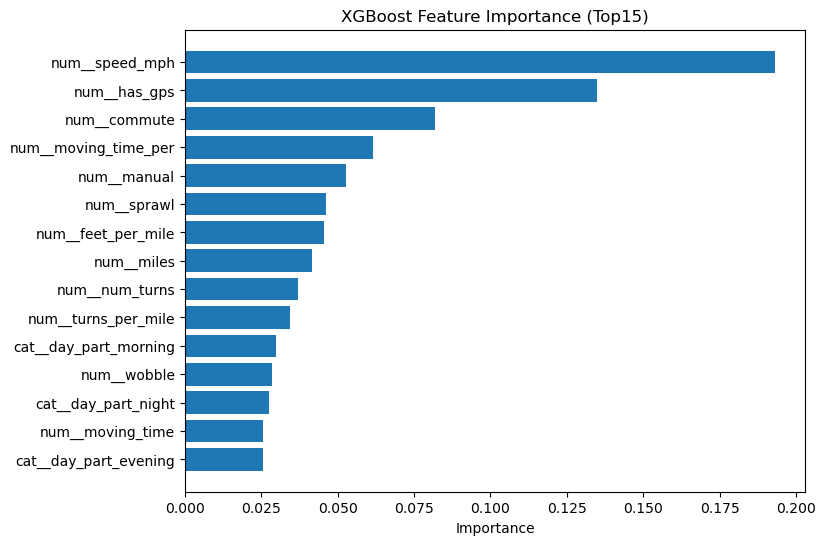

In [146]:
# Plot Top Features
import matplotlib.pyplot as plt 

top_features = importance_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance (Top15)")
plt.xlabel("Importance")

plt.show()

## Global SHAP on tined XGBoost

In [147]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

best_params = best_xgb.named_steps["classifier"].get_params()

# Rebuild a clean model
xgb_clean = XGBClassifier(
    objective = "multi:softprob", 
    num_class=5, 
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42, 
    base_score=0.5, # force scaler float
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    reg_lambda=best_params["reg_lambda"],
    min_child_weight=best_params["min_child_weight"],
    
)

best_xgb_clean = Pipeline(steps=[
    ("preprocessing", preprocessor), 
    ("classifier", xgb_clean),
])

best_xgb_clean.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['day_part']),
                                                 ('num', 'passthrough',
                                                  ['speed_mph', 'miles',
                                                   'moving_time',
                                                   'elapsed_time',
                                                   'moving_time_per',
                                                   'feet_per_mile', 'has_gps',
                                                   'num_turns',
                                                   'turns_per_mile', 'wobble',
                                                   'sprawl', 'hour', 'month',
                                                   'dayofweek', 'is_weekend',
                                                   'commute', 'manual',
                                                   'is_winter',
                                                   'is...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=800,
                               n_jobs=None, num_class=5, ...))])

In [148]:
# 1) Get the fitted preprocessor + fitted booster from  pipeline

import pandas as pd
import numpy as np
import xgboost as xgb
import shap

# pipeline = your trained pipeline (already fit)
pipeline = best_xgb_clean  

preproc = pipeline.named_steps["preprocessing"]
xgb_clf = pipeline.named_steps["classifier"]
booster = xgb_clf.get_booster()

In [149]:
# 2) Transform X_test using the fitted preprocessor + get feature names 

X_test_trans = preproc.transform(X_test)

# IMPORTANT: make sure this becomes a Python list of plain strings
feature_names = preproc.get_feature_names_out()
feature_names = list(feature_names)



In [150]:
# 3) Build DMatrix and get SHAP contributions (TreeSHAP) from XGBoost
# Sample to speed up 
n_sample = 3000
idx = np.random.RandomState(42).choice(X_test.shape[0], size=n_sample, replace=True)

X_test_small = X_test.iloc[idx]
X_test_trans_small = preproc.transform(X_test_small)

feature_names = [str(f) for f in preproc.get_feature_names_out()]

dtest_small = xgb.DMatrix(X_test_trans_small, feature_names=feature_names)
contrib_small = booster.predict(dtest_small, pred_contribs=True)

In [151]:
import numpy as np
import pandas as pd

# contrib_small can be either:
#  - (n, K, p+1)  -> newer multiclass output (your case)
#  - (n, (p+1)*K) -> older multiclass output
#  - (n, p+1)     -> binary/regression

p = len(feature_names)
p1 = p + 1  # includes bias term

if contrib_small.ndim == 3:
    # (n, K, p+1)
    n, K, p1_seen = contrib_small.shape
    if p1_seen != p1:
        raise ValueError(f"Expected last dim p+1={p1} but got {p1_seen}. "
                         f"feature_names length={p}, contrib_small shape={contrib_small.shape}")

    shap_vals = contrib_small[:, :, :-1]   # (n, K, p)
    bias_vals = contrib_small[:, :, -1]    # (n, K)

elif contrib_small.ndim == 2:
    # could be binary/regression (n, p+1) OR multiclass flattened (n, (p+1)*K)
    n, m = contrib_small.shape

    if m == p1:
        # binary/regression style
        K = 1
        shap_vals = contrib_small[:, :-1][:, None, :]   # (n, 1, p)
        bias_vals = contrib_small[:, -1][:, None]       # (n, 1)

    elif m % p1 == 0:
        # multiclass flattened
        K = m // p1
        contrib_3d = contrib_small.reshape(n, K, p1)
        shap_vals = contrib_3d[:, :, :-1]   # (n, K, p)
        bias_vals = contrib_3d[:, :, -1]    # (n, K)

    else:
        raise ValueError(f"Unexpected contrib_small shape {contrib_small.shape} "
                         f"for p1={p1}. Cannot infer K.")

else:
    raise ValueError(f"Unexpected contrib_small ndim: {contrib_small.ndim}")

print("SHAP values shape:", shap_vals.shape)   # (n, K, p)
print("Bias shape:", bias_vals.shape)          # (n, K)

SHAP values shape: (3000, 6, 22)
Bias shape: (3000, 6)


In [152]:
# 4) Global feature importance
# Global importance: mean absolute SHAP across rows AND classes
feature_names = [str(f) for f in feature_names]

global_importance = np.mean(np.abs(shap_vals), axis=(0, 1))  # (p,)

imp_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": global_importance})
      .sort_values("mean_abs_shap", ascending=False)
)

imp_df.head(20)

,feature,mean_abs_shap
3,num__speed_mph,2.033234
8,num__feet_per_mile,0.749260
7,num__moving_time_per,0.694993
13,num__sprawl,0.526367
4,num__miles,0.523438
5,num__moving_time,0.447214
11,num__turns_per_mile,0.403609
6,num__elapsed_time,0.354236
12,num__wobble,0.323032
14,num__hour,0.276010


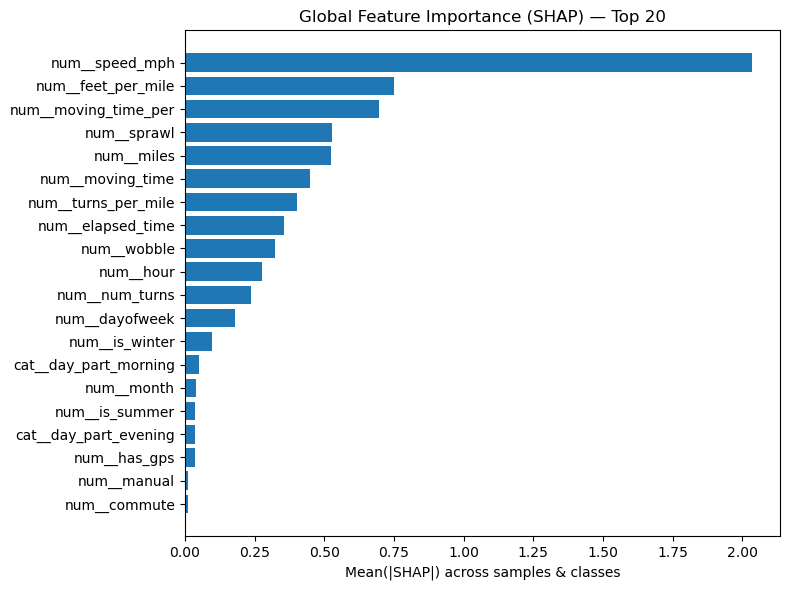

In [153]:
import matplotlib.pyplot as plt

topn = 20
plot_df = imp_df.head(topn).copy()

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"][::-1], plot_df["mean_abs_shap"][::-1])
plt.xlabel("Mean(|SHAP|) across samples & classes")
plt.title(f"Global Feature Importance (SHAP) — Top {topn}")
plt.tight_layout()
plt.show()

In [154]:
import pandas as pd

# XGBoost uses internal feature names like f0, f1, ... unless feature_names were set in the Booster.
# We'll map f{idx} -> your actual feature_names.
fmap = {f"f{i}": feature_names[i] for i in range(len(feature_names))}

# importance types: "gain", "weight", "cover", "total_gain", "total_cover"
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")
cover = booster.get_score(importance_type="cover")

def score_to_df(score_dict, colname):
    # map f0->real feature name; fill missing with 0
    mapped = {fmap.get(k, k): v for k, v in score_dict.items()}
    df_out = pd.DataFrame({"feature": feature_names})
    df_out[colname] = df_out["feature"].map(mapped).fillna(0.0)
    return df_out

gain_df = score_to_df(gain, "gain")
weight_df = score_to_df(weight, "weight")
cover_df = score_to_df(cover, "cover")

builtin_df = gain_df.merge(weight_df, on="feature").merge(cover_df, on="feature")
builtin_df.sort_values("gain", ascending=False).head(20)

,feature,gain,weight,cover
9,num__has_gps,2.164639,62.0,31.161388
3,num__speed_mph,2.153802,4212.0,23.224028
18,num__commute,0.803278,30.0,46.660969
7,num__moving_time_per,0.705986,3304.0,14.742653
19,num__manual,0.704479,74.0,27.159609
13,num__sprawl,0.505554,2373.0,12.723411
8,num__feet_per_mile,0.488343,3202.0,15.449325
4,num__miles,0.476029,2755.0,12.451298
2,cat__day_part_night,0.455719,2.0,52.251026
10,num__num_turns,0.415261,1352.0,12.257984


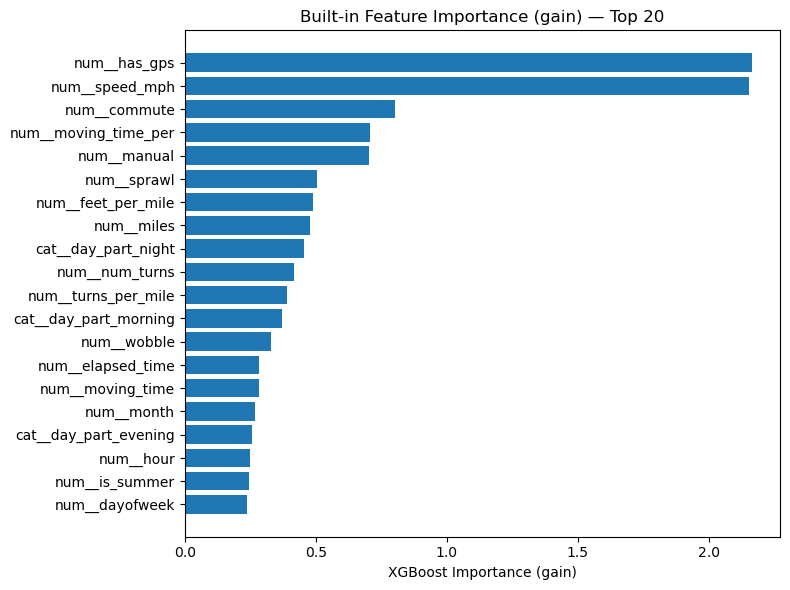

In [155]:
topn = 20
plot_gain = builtin_df.sort_values("gain", ascending=False).head(topn).copy()

plt.figure(figsize=(8, 6))
plt.barh(plot_gain["feature"][::-1], plot_gain["gain"][::-1])
plt.xlabel("XGBoost Importance (gain)")
plt.title(f"Built-in Feature Importance (gain) — Top {topn}")
plt.tight_layout()
plt.show()

In [ ]:
topn = 25  # give yourself a bit more room for rank comparisons

shap_rank = (
    imp_df.copy()
        .reset_index(drop=True)
        .assign(shap_rank=lambda d: d.index + 1)
)

gain_rank = (
    builtin_df.sort_values("gain", ascending=False)
        .reset_index(drop=True)
        .assign(gain_rank=lambda d: d.index + 1)
        [["feature", "gain", "gain_rank"]]
)

compare = (
    shap_rank.merge(gain_rank, on="feature", how="left")
             .sort_values("shap_rank")
)

compare.head(topn)

,feature,mean_abs_shap,shap_rank,gain,gain_rank
0,num__speed_mph,2.033234,1,2.153802,2
1,num__feet_per_mile,0.749260,2,0.488343,7
2,num__moving_time_per,0.694993,3,0.705986,4
3,num__sprawl,0.526367,4,0.505554,6
4,num__miles,0.523438,5,0.476029,8
5,num__moving_time,0.447214,6,0.284155,15
6,num__turns_per_mile,0.403609,7,0.389321,11
7,num__elapsed_time,0.354236,8,0.284664,14
8,num__wobble,0.323032,9,0.327200,13
9,num__hour,0.276010,10,0.248691,18


Exception ignored in: <function ResourceTracker.__del__ at 0x103fc1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104239bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102fedbc0>
Traceback (most recent call last